# Análisis de Finanzas y Riesgo crediticio

#### En quina mesura els clients amb saldos més baixos estan en més risc d'incompliment de crèdit, i com hem d'ajustar les nostres polítiques de crèdit per mitigar aquest risc?

##### librerias

In [51]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt


#### Import dataset

In [52]:

# Ruta CSV 
data_path = "../data/BBDD_bank.csv"

# Cargar el dataset
df = pd.read_csv(
    data_path,
    sep=",",
    encoding="utf-8"
)

# Verificar dimensiones iniciales
df.shape


(10643, 18)

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10643 entries, 0 to 10642
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              10643 non-null  int64  
 1   age             10634 non-null  float64
 2   job             10643 non-null  object 
 3   marital         10643 non-null  object 
 4   education       10643 non-null  object 
 5   credit_default  10643 non-null  int64  
 6   balance         10643 non-null  int64  
 7   housing         10643 non-null  int64  
 8   loan            10643 non-null  int64  
 9   contact         10643 non-null  object 
 10  day             10643 non-null  int64  
 11  month           10643 non-null  object 
 12  duration        10643 non-null  int64  
 13  campaign        10643 non-null  int64  
 14  pdays           10643 non-null  int64  
 15  previous        10643 non-null  int64  
 16  poutcome        10643 non-null  object 
 17  deposit         10643 non-null 

In [54]:
df.head()


,id,age,job,marital,education,credit_default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,1,59.0,admin.,married,secondary,0,2343,1,0,unknown,5,may,1042,1,-1,0,unknown,1
1,2,59.0,admin.,married,secondary,0,2343,1,0,unknown,5,may,1042,1,-1,0,unknown,1
2,3,56.0,admin.,married,secondary,0,45,0,0,unknown,5,may,1467,1,-1,0,unknown,1
3,4,41.0,technician,married,secondary,0,1270,1,0,unknown,5,may,1389,1,-1,0,unknown,1
4,5,55.0,services,married,secondary,0,2476,1,0,unknown,5,may,579,1,-1,0,unknown,1


### 1  Check variables age, housing, job, credit_default y balance

#### 1.1  Check variables age, housing, job y education

In [55]:
# Verificar rango de edad
df["age"].describe()


count    10634.000000
mean        41.254279
std         12.003685
min         18.000000
25%         32.000000
50%         39.000000
75%         49.000000
max         95.000000
Name: age, dtype: float64

In [56]:
# Verificar valores únicos de housing y loan
df["housing"].value_counts(dropna=False), df["loan"].value_counts(dropna=False)


(housing
 0    5660
 1    4983
 Name: count, dtype: int64,
 loan
 0    9271
 1    1372
 Name: count, dtype: int64)

In [57]:
# Número de categorías en job
df["job"].value_counts()


job
management       2447
blue-collar      1830
technician       1737
admin.           1280
services          881
retired           755
self-employed     388
student           354
unemployed        338
entrepreneur      308
housemaid         257
unknown            68
Name: count, dtype: int64

In [58]:
# Número de categorías en education
df["education"].value_counts()


education
secondary    5217
tertiary     3527
primary      1419
unknown       480
Name: count, dtype: int64

#### 1.2 Análisis de la variable credit_default y balance

In [59]:
df["credit_default"].value_counts(), df["credit_default"].value_counts(normalize=True) * 100


(credit_default
 0    10488
 1      155
 Name: count, dtype: int64,
 credit_default
 0    98.543644
 1     1.456356
 Name: proportion, dtype: float64)

In [60]:
df["balance"].describe()

count    10643.000000
mean      1536.690595
std       3223.277326
min      -6847.000000
25%        127.000000
50%        558.000000
75%       1729.500000
max      81204.000000
Name: balance, dtype: float64

In [61]:
# Estadísticas descriptivas ampliadas de balance
df["balance"].describe(percentiles=[0.01, 0.05, 0.10, 0.90, 0.95, 0.99])


count    10643.000000
mean      1536.690595
std       3223.277326
min      -6847.000000
1%        -516.480000
5%         -48.800000
10%          0.000000
50%        558.000000
90%       3911.200000
95%       6004.900000
99%      13101.540000
max      81204.000000
Name: balance, dtype: float64

In [62]:
# Proporción de clientes por tipo de balance
balance_area_summary = pd.Series({
    "negativo": (df["balance"] < 0).mean() * 100,
    "cero": (df["balance"] == 0).mean() * 100,
    "positivo": (df["balance"] > 0).mean() * 100
}).round(2)

balance_area_summary


negativo     6.07
cero         6.83
positivo    87.10
dtype: float64

In [63]:
# Estadísticas solo balances positivos
df.loc[df["balance"] > 0, "balance"].describe(
    percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]
)


count     9270.000000
mean      1786.734412
std       3380.539232
min          1.000000
10%         85.000000
25%        262.000000
50%        740.000000
75%       2037.000000
90%       4333.000000
max      81204.000000
Name: balance, dtype: float64

### 2. Creacion Columnas  balance_segment y age_group



#### 2.1 columna de segmentación de balance (balance_segment)


In [64]:

# Crear columna de segmentación de balance
df["balance_segment"] = np.nan

# Segmento negativo
df.loc[df["balance"] < 0, "balance_segment"] = "negativo"

# Segmento cero + positivo
non_negative_mask = df["balance"] >= 0

# Subsegmentar cero y positivos en tres grupos
df.loc[non_negative_mask, "balance_segment"] = pd.qcut(
    df.loc[non_negative_mask, "balance"],
    q=3,
    labels=["bajo", "medio", "alto"]
)


C:\Users\edo\AppData\Local\Temp\ipykernel_29856\2051878538.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'negativo' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[df["balance"] < 0, "balance_segment"] = "negativo"


In [65]:
# Verificar distribución de los segmentos
df["balance_segment"].value_counts()


balance_segment
bajo        3338
alto        3333
medio       3326
negativo     646
Name: count, dtype: int64

#### 2.2 columna franjas de edad ("age_group" - 18-30, 31-45, 46-60, 60+)


In [66]:
# Crear grupos de edad
df["age_group"] = pd.cut(
    df["age"],
    bins=[18, 30, 45, 60, 100],
    labels=["18-30", "31-45", "46-60", "60+"]
)


In [67]:
# Verificar distribución de los segmentos
df["age_group"].value_counts()


age_group
31-45    5228
46-60    2867
18-30    1925
60+       606
Name: count, dtype: int64

### 3. relacion balance_segment y riesgo

####  3.1 % default por balance_segment

In [68]:
# Tamaño del grupo balance_segment y porcentaje de default
balance_segment_summary = (
    df
    .groupby("balance_segment")
    .agg(
        total_clientes=("credit_default", "count"),
        porcentaje_default=("credit_default", lambda x: round(x.mean() * 100, 2))
    )
    .sort_values(by="porcentaje_default", ascending=False)
)

balance_segment_summary


,total_clientes,porcentaje_default
balance_segment,,
negativo,646,11.46
bajo,3338,1.89
medio,3326,0.45
alto,3333,0.09


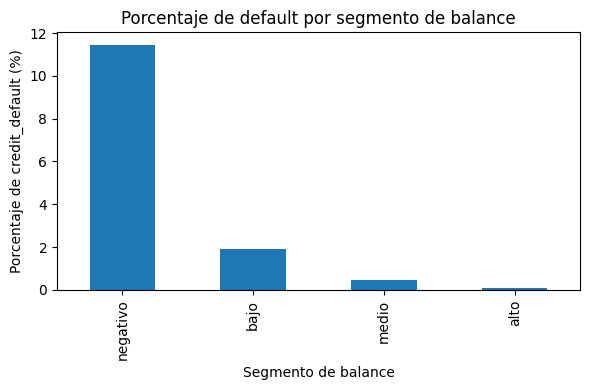

In [69]:
import matplotlib.pyplot as plt

# Datos para el gráfico principal
default_main = (
    df
    .groupby("balance_segment")["credit_default"]
    .mean()
    .mul(100)
    .round(2)
    .reindex(["negativo", "bajo", "medio", "alto"])
)

# Gráfico de barras
plt.figure(figsize=(6, 4))
default_main.plot(kind="bar")
plt.ylabel("Porcentaje de credit_default (%)")
plt.xlabel("Segmento de balance")
plt.title("Porcentaje de default por segmento de balance")
plt.tight_layout()
plt.show()


#### 3.2 % default y balance vs loan 

In [70]:
# Tabla balance_segment x loan (% credit_default)
default_by_balance_loan = (
    df
    .groupby(["balance_segment", "loan"])["credit_default"]
    .mean()
    .mul(100)
    .round(2)
    .unstack()
)
default_by_balance_loan.rename(
    columns={
        0: "loan_no_%default",
        1: "loan_yes_%default"
    },
    inplace=True
)
default_by_balance_loan


loan,loan_no_%default,loan_yes_%default
balance_segment,,
alto,0.10,0.00
bajo,1.40,4.70
medio,0.38,0.94
negativo,10.63,13.24


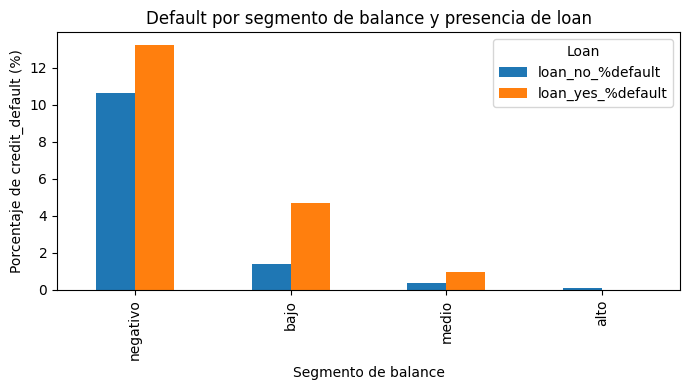

In [71]:

# Reordenar filas para coherencia visual
plot_loan = default_by_balance_loan.reindex(
    ["negativo", "bajo", "medio", "alto"]
)

plot_loan.plot(
    kind="bar",
    figsize=(7, 4)
)

plt.ylabel("Porcentaje de credit_default (%)")
plt.xlabel("Segmento de balance")
plt.title("Default por segmento de balance y presencia de loan")
plt.legend(title="Loan")
plt.tight_layout()
plt.show()


#### 3.3 % default y balance vs housing

In [72]:
# Tabla balance_segment x housing 
default_by_balance_housing = (
    df
    .groupby(["balance_segment", "housing"])["credit_default"]
    .mean()
    .mul(100)
    .round(2)
    .unstack()
)


default_by_balance_housing.rename(
    columns={
        0: "housing_no_%default",
        1: "housing_yes_%default"
    },
    inplace=True
)

default_by_balance_housing



housing,housing_no_%default,housing_yes_%default
balance_segment,,
alto,0.00,0.23
bajo,2.52,1.19
medio,0.40,0.51
negativo,14.63,10.37


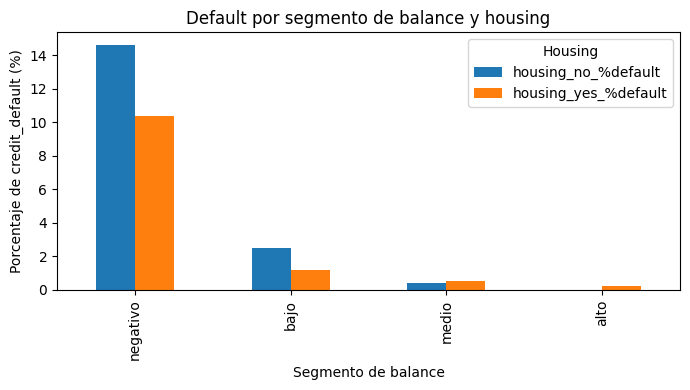

In [73]:
plot_housing = default_by_balance_housing.reindex(
    ["negativo", "bajo", "medio", "alto"]
)

plot_housing.plot(
    kind="bar",
    figsize=(7, 4)
)

plt.ylabel("Porcentaje de credit_default (%)")
plt.xlabel("Segmento de balance")
plt.title("Default por segmento de balance y housing")
plt.legend(title="Housing")
plt.tight_layout()
plt.show()


####  3.4 % deafult y balance vs age group (18-30, 31-45, 46-60, 60+)

In [74]:
# Tabla balance_segment x age_group (% credit_default)
default_by_balance_age = (
    df
    .groupby(["balance_segment", "age_group"])["credit_default"]
    .mean()
    .mul(100)
    .round(2)
    .unstack()
)

default_by_balance_age


C:\Users\edo\AppData\Local\Temp\ipykernel_29856\1609569030.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["balance_segment", "age_group"])["credit_default"]


age_group,18-30,31-45,46-60,60+
balance_segment,,,,
alto,0.21,0.00,0.20,0.00
bajo,2.42,1.72,2.09,0.00
medio,0.30,0.43,0.58,0.61
negativo,11.02,10.95,12.85,0.00


C:\Users\edo\AppData\Local\Temp\ipykernel_29856\2199753999.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["balance_segment", "age_group"])["credit_default"]


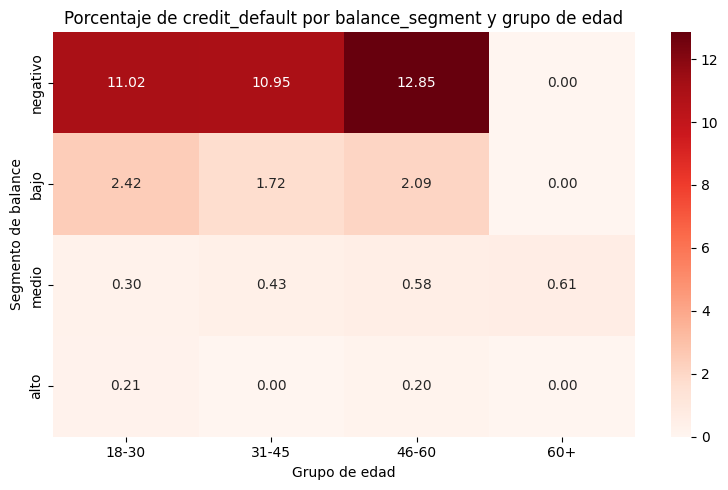

In [80]:
balance_order = ["negativo", "bajo", "medio", "alto"]

heatmap_age = (
    df
    .groupby(["balance_segment", "age_group"])["credit_default"]
    .mean()
    .mul(100)
    .round(2)
    .unstack()
    .reindex(balance_order)
)

plt.figure(figsize=(8, 5))
sns.heatmap(
    heatmap_age,
    annot=True,
    fmt=".2f",
    cmap="Reds"
)
plt.title("Porcentaje de credit_default por balance_segment y grupo de edad")
plt.ylabel("Segmento de balance")
plt.xlabel("Grupo de edad")
plt.tight_layout()
plt.show()



####  3.5 % default y balance vs education


In [76]:
# Tabla balance_segment x education (% credit_default)
default_by_balance_education = (
    df
    .groupby(["balance_segment", "education"])["credit_default"]
    .mean()
    .mul(100)
    .round(2)
    .unstack()
    .reindex(["negativo", "bajo", "medio", "alto"])
)

default_by_balance_education


education,primary,secondary,tertiary,unknown
balance_segment,,,,
negativo,14.29,10.37,9.63,31.25
bajo,1.98,1.71,1.98,3.03
medio,0.77,0.41,0.47,0.00
alto,0.00,0.14,0.08,0.00


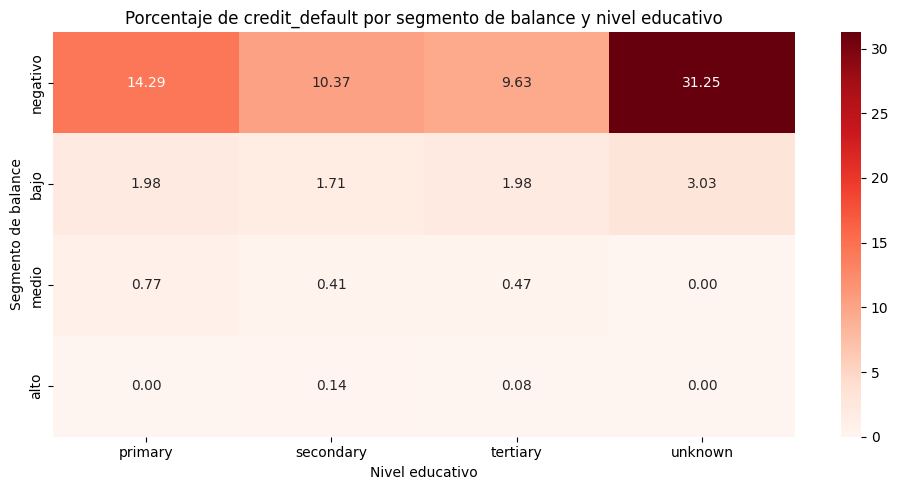

In [ ]:

plt.figure(figsize=(10, 5))
sns.heatmap(
    default_by_balance_education,
    annot=True,
    fmt=".2f",
    cmap="Reds"
)
plt.title("Porcentaje de credit_default por segmento de balance y nivel educativo")
plt.ylabel("Segmento de balance")
plt.xlabel("Nivel educativo")
plt.tight_layout()
plt.show()


####  3.6 % default y balance vs job


In [78]:
# Tabla balance_segment x job (% credit_default)
default_by_balance_job = (
    df
    .groupby(["balance_segment", "job"])["credit_default"]
    .mean()
    .mul(100)
    .round(2)
    .unstack()
    .reindex(["negativo", "bajo", "medio", "alto"])
)

default_by_balance_job



job,admin.,blue-collar,entrepreneur,housemaid,management,retired,self-employed,services,student,technician,unemployed,unknown
balance_segment,,,,,,,,,,,,
negativo,3.49,13.27,26.92,33.33,9.28,9.52,11.11,6.33,NaN,12.75,33.33,NaN
bajo,1.13,1.57,2.80,2.91,2.43,1.24,3.94,0.34,0.77,2.22,3.06,5.88
medio,0.00,0.85,0.00,3.28,0.55,0.47,0.00,0.35,0.00,0.36,0.00,0.00
alto,0.31,0.00,0.00,0.00,0.23,0.00,0.00,0.00,0.00,0.00,0.00,0.00


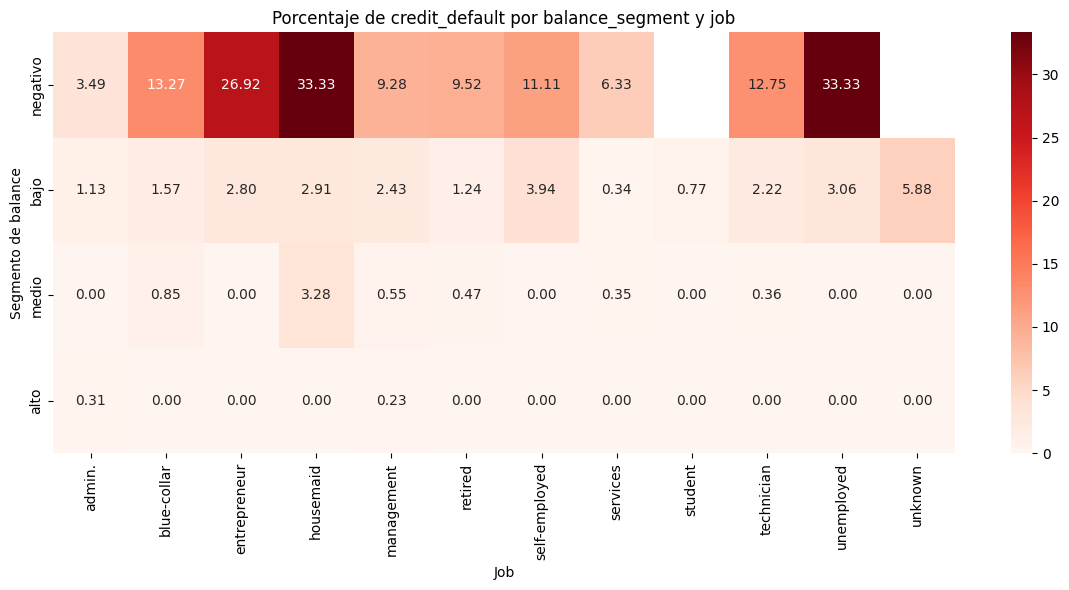

In [79]:
balance_order = ["negativo", "bajo", "medio", "alto"]


# Tabla para heatmap: balance_segment x job
heatmap_job = (
    df
    .groupby(["balance_segment", "job"])["credit_default"]
    .mean()
    .mul(100)
    .round(2)
    .unstack()
    .reindex(balance_order)
)

plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_job,
    annot=True,
    fmt=".2f",
    cmap="Reds"
)
plt.title("Porcentaje de credit_default por balance_segment y job")
plt.ylabel("Segmento de balance")
plt.xlabel("Job")
plt.tight_layout()
plt.show()



### 4. Insights, limitaciones y políticas de crédito